In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_predict, learning_curve

np.random.seed(42)

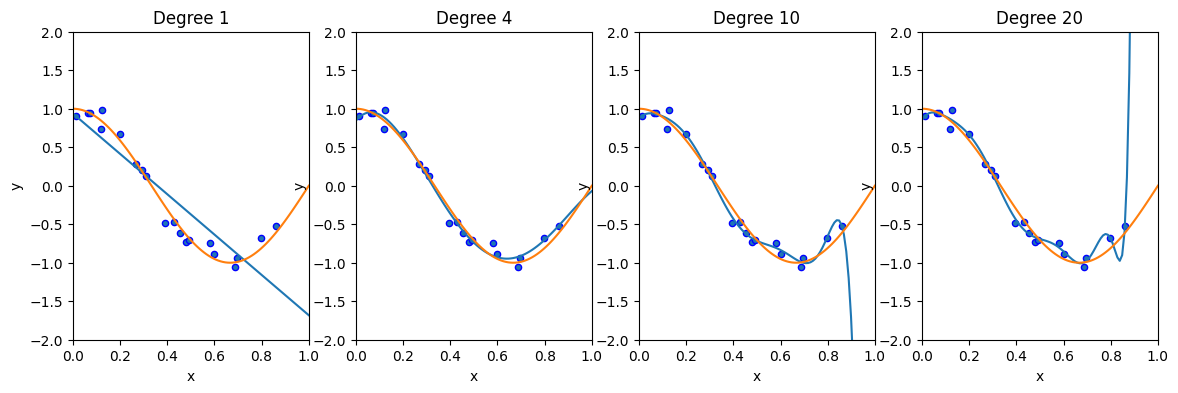

In [15]:
def func(X):
    return np.cos(1.5 * np.pi * X)

X = np.sort(np.random.rand(20))
y = func(X) + np.random.randn(20) * 0.1

degrees = [1, 4, 10, 20]
plt.figure(figsize=(14,4))

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("poly", polynomial_features), ("linear", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, func(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.title(f"Degree {degrees[i]}")


In [ ]:
X_wide = np.random.rand(200, 1)
y_wide = func(X_wide).ravel() + np.random.randn(200) * 0.1

X_train, X_temp, y_train, y_temp = train_test_split(X_wide, y_wide, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
